# Fraud Detection Using Machine Learning

Submitted by: Ranjan Verma

This project detects fraudulent online payment transactions using supervised machine learning algorithms.

## Problem Statement

Online payment fraud causes financial losses. The goal is to build a machine learning model that identifies fraudulent transactions accurately.

In [48]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/paysim.csv')

# Preprocessing Data

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [73]:
print(df['type'].unique())

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.drop(columns = ['nameOrig', 'nameDest', 'isFlaggedFraud'], axis = 1, inplace = True)

In [7]:
df.isnull().sum()

,0
step,0
type,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [8]:
df.duplicated().sum()

np.int64(543)

In [9]:
df = df.drop_duplicates()

In [10]:
df.shape

(6362077, 8)

In [11]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

# EDA

<Axes: >

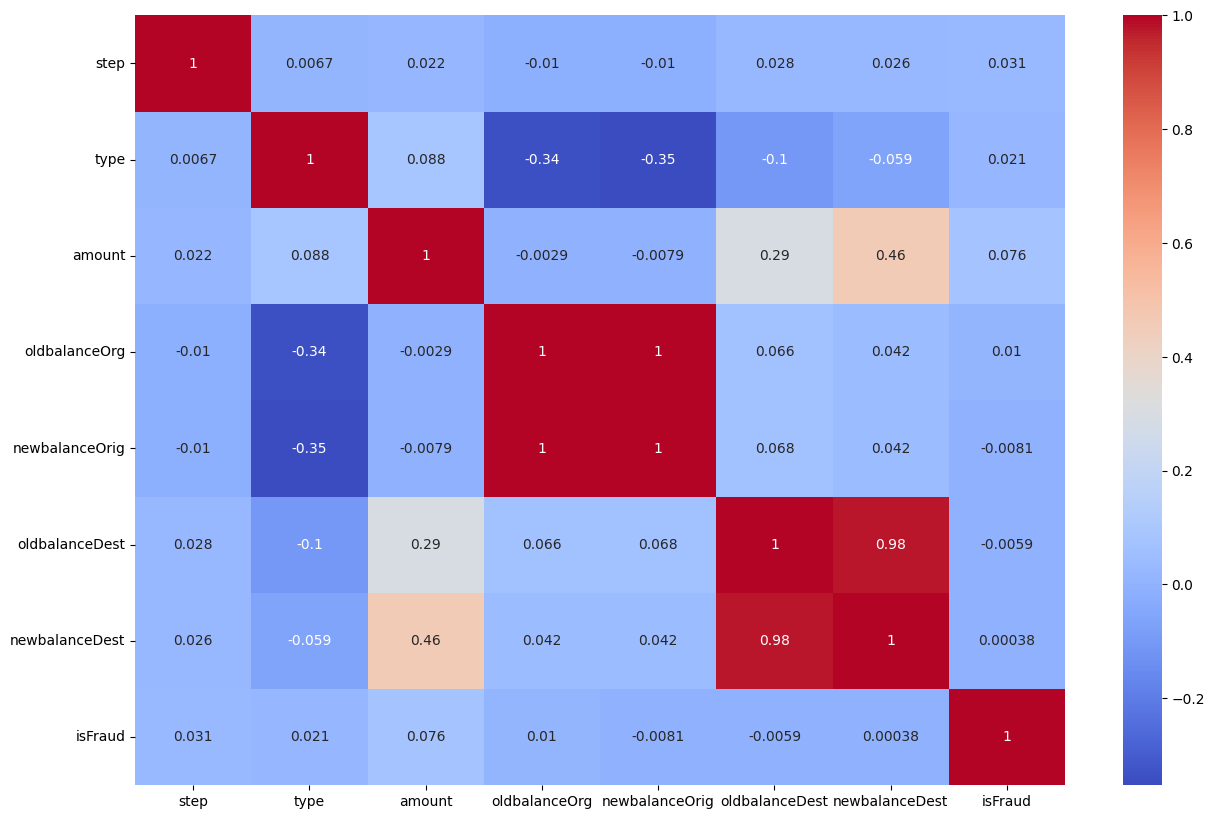

In [12]:
corr = df.corr()

plt.figure(figsize = (15, 10))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')

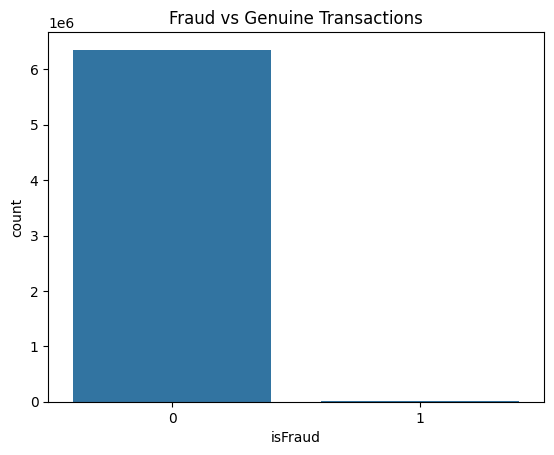

In [13]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

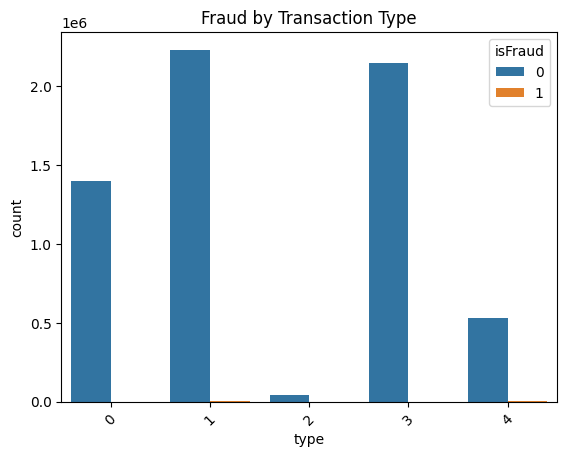

In [14]:
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()

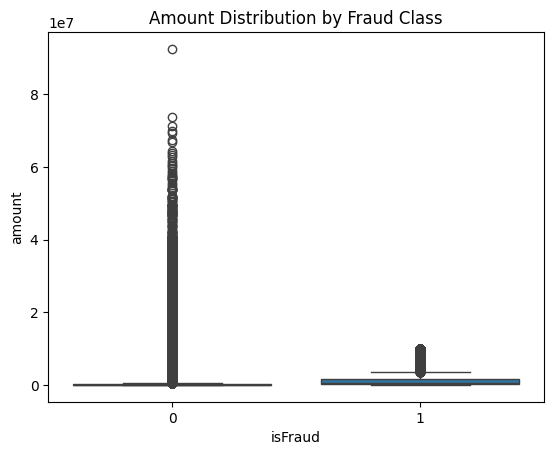

In [15]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Amount Distribution by Fraud Class")
plt.show()

# Splitting the Dataset

In [16]:
# Using less data to decrease computing power
df = df.sample(300000, random_state=42)

In [17]:
X = df.drop('isFraud', axis = 1)
y = df['isFraud']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

# Training Models

## Logistic Regression

In [38]:
lr = LogisticRegression(class_weight = 'balanced')
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced')

In [39]:
pred_lr = lr.predict(X_test)

In [40]:
print("Logistic Regression")

print("Accuracy Score: ", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Logistic Regression
Accuracy Score:  0.95655
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     59923
           1       0.03      0.96      0.05        77

    accuracy                           0.96     60000
   macro avg       0.51      0.96      0.52     60000
weighted avg       1.00      0.96      0.98     60000



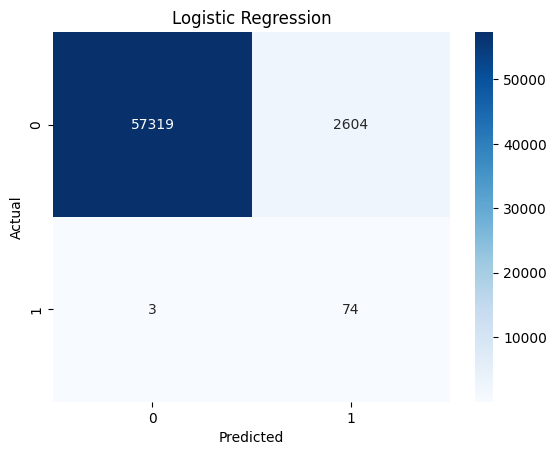

In [41]:
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [59]:
lr_acc  = accuracy_score(y_test, pred_lr)
lr_pre  = precision_score(y_test, pred_lr)
lr_rec  = recall_score(y_test, pred_lr)
lr_f1   = f1_score(y_test, pred_lr)

## Decision Tree

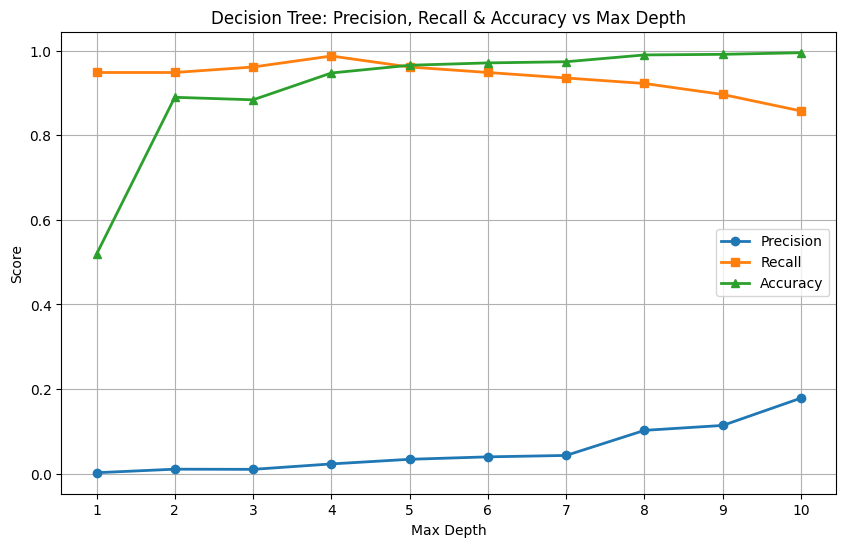

In [42]:
# Entropy
depths = range(1, 11)

precision_scores = []
recall_scores = []
accuracy_scores = []

for d in depths:

    dt = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42, class_weight= 'balanced')

    dt.fit(X_train, y_train)
    pred_dt = dt.predict(X_test)

    precision_scores.append(precision_score(y_test, pred_dt))
    recall_scores.append(recall_score(y_test, pred_dt))
    accuracy_scores.append(accuracy_score(y_test, pred_dt))

plt.figure(figsize=(10,6))

plt.plot(depths, precision_scores, marker='o', linewidth=2, label='Precision')
plt.plot(depths, recall_scores, marker='s', linewidth=2, label='Recall')
plt.plot(depths, accuracy_scores, marker='^', linewidth=2, label='Accuracy')

plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("Decision Tree: Precision, Recall & Accuracy vs Max Depth")
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

We are getting best and Reasonable results at max_depth 7

In [43]:
dt = DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=7, random_state=42)

In [44]:
pred_dt = dt.predict(X_test)

In [45]:
print("Decision Tree")

print("Accuracy Score: ", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))

Decision Tree
Accuracy Score:  0.97345
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     59923
           1       0.04      0.94      0.08        77

    accuracy                           0.97     60000
   macro avg       0.52      0.95      0.53     60000
weighted avg       1.00      0.97      0.99     60000



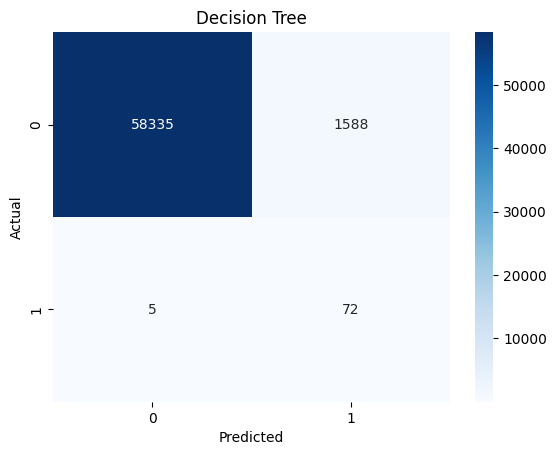

In [46]:
cm = confusion_matrix(y_test, pred_dt)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
dt_acc  = accuracy_score(y_test, pred_dt)
dt_pre  = precision_score(y_test, pred_dt)
dt_rec  = recall_score(y_test, pred_dt)
dt_f1   = f1_score(y_test, pred_dt)

## Random Forest

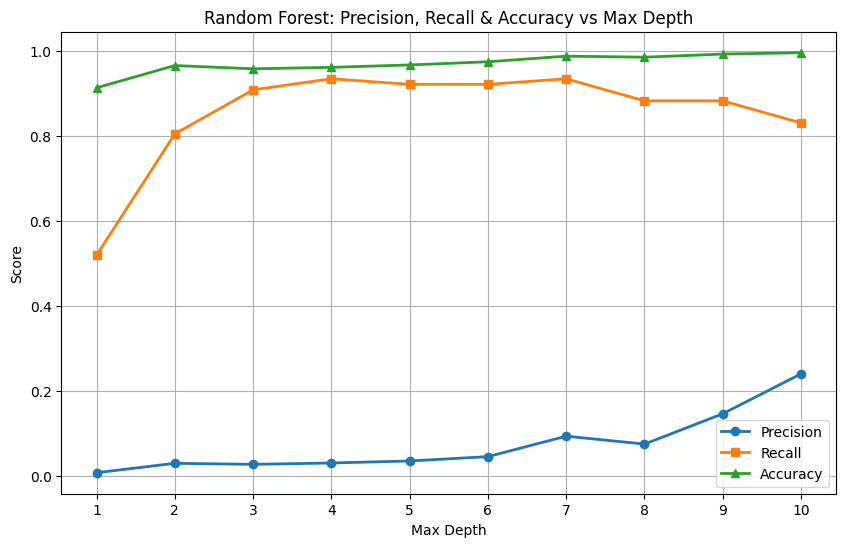

In [47]:
depths = range(1, 11)

precision_scores = []
recall_scores = []
accuracy_scores = []

for d in depths:

    rf = RandomForestClassifier(criterion='gini', max_depth=d, random_state=42, n_estimators = 30, n_jobs = -1, class_weight='balanced')

    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    precision_scores.append(precision_score(y_test, pred_rf))
    recall_scores.append(recall_score(y_test, pred_rf))
    accuracy_scores.append(accuracy_score(y_test, pred_rf))

plt.figure(figsize=(10,6))

plt.plot(depths, precision_scores, marker='o', linewidth=2, label='Precision')
plt.plot(depths, recall_scores, marker='s', linewidth=2, label='Recall')
plt.plot(depths, accuracy_scores, marker='^', linewidth=2, label='Accuracy')

plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("Random Forest: Precision, Recall & Accuracy vs Max Depth")
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

We are getting best and Reasonable results at max_depth 7

In [49]:
rf = RandomForestClassifier(criterion='gini', max_depth=d, random_state=42, n_estimators = 30, n_jobs = -1, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=30,
                       n_jobs=-1, random_state=42)

In [50]:
pred_rf = rf.predict(X_test)

In [52]:
print("Random Forest")

print("Accuracy Score: ", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Random Forest
Accuracy Score:  0.9964166666666666
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59923
           1       0.24      0.83      0.37        77

    accuracy                           1.00     60000
   macro avg       0.62      0.91      0.69     60000
weighted avg       1.00      1.00      1.00     60000



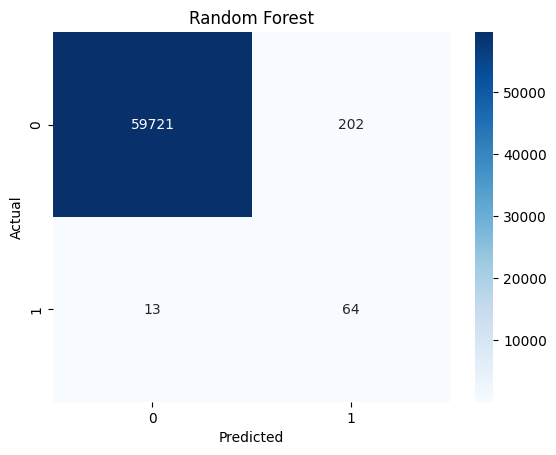

In [53]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
rf_acc  = accuracy_score(y_test, pred_rf)
rf_pre  = precision_score(y_test, pred_rf)
rf_rec  = recall_score(y_test, pred_rf)
rf_f1   = f1_score(y_test, pred_rf)

## Naive Bayes

In [55]:
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [56]:
pred_nb = nb.predict(X_test)

In [57]:
print("Gaussian Naive Bayes")

print("Accuracy Score: ", accuracy_score(y_test, pred_nb))
print(classification_report(y_test, pred_nb))

Gaussian Naive Bayes
Accuracy Score:  0.9939333333333333
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     59923
           1       0.05      0.22      0.09        77

    accuracy                           0.99     60000
   macro avg       0.53      0.61      0.54     60000
weighted avg       1.00      0.99      1.00     60000



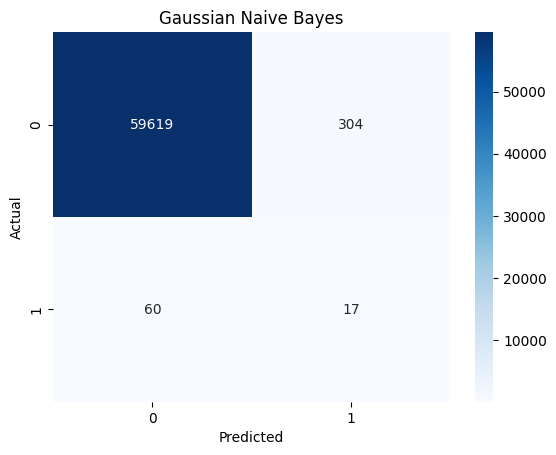

In [58]:
cm = confusion_matrix(y_test, pred_nb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [62]:
nb_acc  = accuracy_score(y_test, pred_nb)
nb_pre  = precision_score(y_test, pred_nb)
nb_rec  = recall_score(y_test, pred_nb)
nb_f1   = f1_score(y_test, pred_nb)

# Comparision Table

In [68]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Naive Bayes'],
    'Accuracy':  [lr_acc, dt_acc, rf_acc, nb_acc],
    'Precision': [lr_pre, dt_pre, rf_pre, nb_pre],
    'Recall':    [lr_rec, dt_rec, rf_rec, nb_rec],
    'F1 Score':  [lr_f1, dt_f1, rf_f1, nb_f1]
})

In [69]:
results[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = \
results[['Accuracy', 'Precision', 'Recall', 'F1 Score']] * 100

In [70]:
results = results.round(3)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,95.655,2.763,96.104,5.372
1,Decision Tree,97.345,4.337,93.506,8.290
2,Random Forest,99.642,24.060,83.117,37.318
3,Naive Bayes,99.393,5.296,22.078,8.543


## Final Model Selection: Random Forest

After evaluating all machine learning models, **Random Forest** was selected as the final model for fraud detection. It achieved the **highest accuracy**, **best precision**, and **highest F1-score** among all tested models while also maintaining strong recall.

This indicates that Random Forest was able to detect fraudulent transactions effectively while producing fewer false positives compared to other models. Due to its balanced performance, robustness, and reliability, Random Forest is the most suitable model for this project.

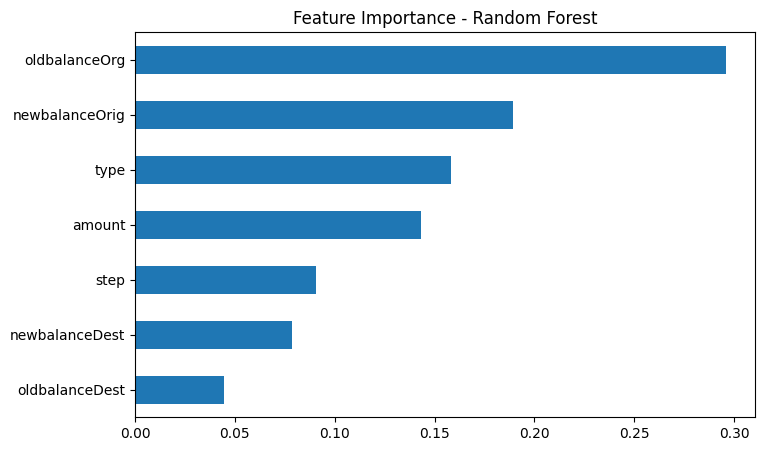

In [75]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance - Random Forest")
plt.show()

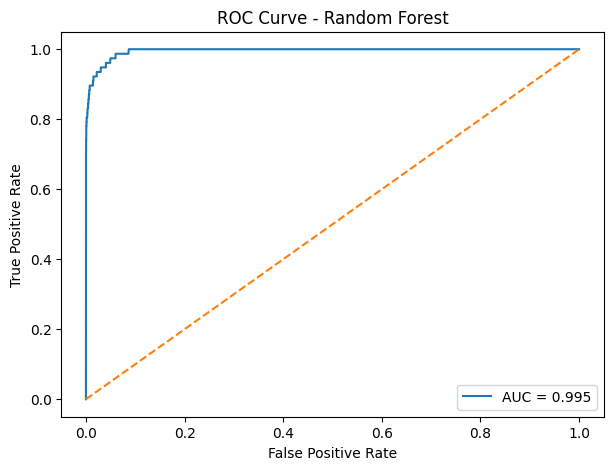

In [76]:
y_prob = rf.predict_proba(X_test)[:,1]

auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()